In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/Users/chenxu/Work/comm-ls")

import os, sys
os.chdir(ROOT)

In [28]:
MINER_FEATURE_VERSION = "raw"  # Use "chained" for the roll-adjusted robustness check.
MINER_FEATURES = {
    "raw":     "hg_gc_matched_ratio_ma_gap_3d_50d_raw",
    "chained": "hg_gc_matched_ratio_ma_gap_3d_50d_chained",
}

SLEEVE_CONFIG = {
    "alloys": {
        "tickers": ["ATI", "CRS", "MTRN", "HWM"],
        'feature': 'carry',
        "threshold": 0.01,
        "side_mult": -1,
        "mode": "fixed_hold",
        "hold_days": 21,
        "weights": {'ATI': 0.25, 'CRS': 0.25, 'MTRN': 0.25, 'HWM': 0.25},
    },
    "miners": {
        "tickers": ["FSUGY", "BHP", "RIO"],
        'feature': MINER_FEATURES[MINER_FEATURE_VERSION],
        "threshold": 0.020,
        "side_mult": -1,
        "mode": "persistent_binary",
        "weights": {'FSUGY': 0.30, 'BHP': 0.40, 'RIO': 0.30},
    }
}


In [29]:
def load_fut_continuous_data(ticker: str, root=ROOT):
    p = root / f'data/comm/carry_data/{ticker}.csv'
    df = pd.read_csv(p, index_col='date', parse_dates=['date'])
    return df.sort_index()


def load_stock_data(ticker, comm="METAL", root=ROOT):
    comm = comm.upper()
    cache_path = root / f"data/cache/feature_return/{comm}-multi_return.parquet"

    df = pd.read_parquet(cache_path)
    out = df[df["ticker"].eq(ticker)].copy()
    if not out.empty:
        out["date"] = pd.to_datetime(out["date"]).dt.normalize()
        return out.sort_values("date").reset_index(drop=True)

    # Hedge/ETF fallback keeps notebook use working before a cache rebuild.
    if ticker in {"SPY", "XLE", "XME", "QQQ", "CRAK"}:
        path = root / f"data/equity/yfinance/{ticker}.csv"
        out = pd.read_csv(path)
        out["date"] = pd.to_datetime(out["date"]).dt.normalize()
        price_col = "adj_close" if "adj_close" in out.columns else "close"
        price = pd.to_numeric(out[price_col], errors="coerce")
        out["raw_return"] = np.log(price).diff()
        return out.sort_values("date").reset_index(drop=True)

    return out


def load_feature_data(feature_name, symbol="CL", root=ROOT):
    path = root / "data/processed/commodity_signals.parquet"
    df = pd.read_parquet(path)

    df["date"] = pd.to_datetime(df["date"])

    if "symbol" in df.columns:
        df = df[df["symbol"].eq(symbol)].copy()

    if feature_name not in df.columns:
        matches = [c for c in df.columns if feature_name.lower() in c.lower()]
        raise KeyError(f"{feature_name} not found. Similar columns: {matches[:20]}")

    out = df[["date", "symbol", feature_name]].copy()
    out = out.rename(columns={feature_name: "feature_value"})
    out["feature_name"] = feature_name
    out["feature_source_valid"] = out["feature_value"].notna()

    # 防止同一个 symbol/date 仍有重复
    out = out.sort_values("date").drop_duplicates(["date", "symbol"], keep="last")
    out = out.sort_values("date").reset_index(drop=True)

    return out


def join_stock_feature(stock_df, feature_df, how="left"):
    s = stock_df.copy()
    f = feature_df.copy()

    s["date"] = pd.to_datetime(s["date"])
    f["date"] = pd.to_datetime(f["date"])

    out = s.merge(f, on="date", how=how)
    out = out.sort_values("date").reset_index(drop=True)

    feature_name = f["feature_name"].dropna().iloc[-1]

    calendar_like = (
        feature_name == "calendar_dec_annualized_carry"
        or feature_name.startswith("next_dec_")
        or feature_name.startswith("mar_dec_")
        or feature_name.startswith("jun_dec_")
        or feature_name.startswith("sep_dec_")
    )

    if calendar_like:
        valid_state = out["feature_source_valid"].ffill().fillna(False).astype(bool)
        out["feature_value"] = out["feature_value"].ffill().where(valid_state)
    else:
        out["feature_value"] = out["feature_value"].ffill()

    return out

In [ ]:
# Historical-only audit helper. The miners sleeve consumes the arrival-safe
# METALS cache, whose contract builder adds live_data only when BBG is missing.
def load_hg_crack_month(
    month_list: str | list[str] = "HKUZ",
    roll_by: str = "open int",
    roll_anchor: str = "joint",
    start_year: int = 2010,
    end_year: int = 2026,
    liquidity_window: int = 3,
    liquidity_lag: int = 1,
    root_dir: str | Path = "data/comm",
) -> pd.DataFrame:
    """
    Build matched GC/SI/HG continuous series.

    Contract mapping:
        SI/HG H (Mar) -> GC M (Jun)
        SI/HG K (May) -> GC Q (Aug)
        SI/HG U (Sep) -> GC V (Oct)
        SI/HG Z (Dec) -> GC Z (Dec)

    roll_anchor:
        "joint": geometric mean of SI and HG liquidity
        "SI":    SI liquidity only
        "HG":    HG liquidity only

    Returns contract-local log returns, so contract rolls do not create
    artificial return jumps.
    """
    root_dir = Path(root_dir)

    if isinstance(month_list, str):
        months = list(month_list.upper())
    else:
        months = [str(month).upper() for month in month_list]

    gc_month_map = {
        "H": "M",
        "K": "Q",
        "U": "V",
        "Z": "Z",
    }
    month_order = {
        code: i
        for i, code in enumerate("FGHJKMNQUVXZ", start=1)
    }

    invalid_months = sorted(set(months) - set(gc_month_map))
    if invalid_months:
        raise ValueError(
            f"Unsupported SI/HG months: {invalid_months}. "
            f"Supported months are {sorted(gc_month_map)}."
        )

    if roll_anchor not in {"joint", "SI", "HG"}:
        raise ValueError("roll_anchor must be 'joint', 'SI', or 'HG'")

    def read_contract(symbol: str, year: int, month: str) -> pd.DataFrame:
        path = root_dir / symbol / f"{year}{month}.csv"
        if not path.exists():
            raise FileNotFoundError(f"Missing contract file: {path}")

        df = pd.read_csv(path)
        required = {"date", "px_settle", roll_by}
        missing = required - set(df.columns)
        if missing:
            raise KeyError(f"{path} is missing columns: {sorted(missing)}")

        df["date"] = pd.to_datetime(df["date"]).dt.normalize()
        df = (
            df.sort_values("date")
            .drop_duplicates("date", keep="last")
            .set_index("date")
        )

        df["px_settle"] = pd.to_numeric(
            df["px_settle"], errors="coerce"
        )
        df[roll_by] = pd.to_numeric(df[roll_by], errors="coerce")

        # Calculate returns inside each individual contract before rolling.
        df["contract_ret"] = np.log(df["px_settle"]).diff()
        return df

    contract_pairs = []

    for year in range(start_year, end_year + 1):
        for si_hg_month in months:
            gc_month = gc_month_map[si_hg_month]

            pair = {
                "sort_key": (year, month_order[si_hg_month]),
                "gc_contract": f"{year}{gc_month}",
                "si_contract": f"{year}{si_hg_month}",
                "hg_contract": f"{year}{si_hg_month}",
                "GC": read_contract("GC", year, gc_month),
                "SI": read_contract("SI", year, si_hg_month),
                "HG": read_contract("HG", year, si_hg_month),
            }

            si_liquidity = (
                pair["SI"][roll_by]
                .rolling(liquidity_window, min_periods=1)
                .mean()
                .shift(liquidity_lag)
            )
            hg_liquidity = (
                pair["HG"][roll_by]
                .rolling(liquidity_window, min_periods=1)
                .mean()
                .shift(liquidity_lag)
            )

            if roll_anchor == "SI":
                pair["liquidity"] = si_liquidity
            elif roll_anchor == "HG":
                pair["liquidity"] = hg_liquidity
            else:
                liquidity = pd.concat(
                    {
                        "SI": si_liquidity,
                        "HG": hg_liquidity,
                    },
                    axis=1,
                    sort=False,
                )
                pair["liquidity"] = np.sqrt(
                    liquidity["SI"].clip(lower=0)
                    * liquidity["HG"].clip(lower=0)
                )

            contract_pairs.append(pair)

    contract_pairs.sort(key=lambda pair: pair["sort_key"])

    all_dates = pd.DatetimeIndex([])
    for pair in contract_pairs:
        all_dates = all_dates.union(pair["HG"].index)
        all_dates = all_dates.union(pair["SI"].index)

    all_dates = all_dates.sort_values()

    def value(series: pd.Series, date: pd.Timestamp) -> float:
        result = series.get(date, np.nan)
        return float(result) if pd.notna(result) else np.nan

    rows = []
    active_pair = 0

    for date in all_dates:
        # Roll forward once the next contract pair has greater liquidity.
        while active_pair + 1 < len(contract_pairs):
            current_score = value(
                contract_pairs[active_pair]["liquidity"], date
            )
            next_score = value(
                contract_pairs[active_pair + 1]["liquidity"], date
            )

            should_roll = (
                np.isfinite(next_score)
                and (
                    not np.isfinite(current_score)
                    or next_score > current_score
                )
            )
            if not should_roll:
                break

            active_pair += 1

        pair = contract_pairs[active_pair]

        gc_settle = value(pair["GC"]["px_settle"], date)
        si_settle = value(pair["SI"]["px_settle"], date)
        hg_settle = value(pair["HG"]["px_settle"], date)

        if not all(np.isfinite([gc_settle, si_settle, hg_settle])):
            continue

        rows.append({
            "date": date,
            "gc_contract": pair["gc_contract"],
            "si_contract": pair["si_contract"],
            "hg_contract": pair["hg_contract"],
            "roll_liquidity": value(pair["liquidity"], date),
            "gc_settle": gc_settle,
            "si_settle": si_settle,
            "hg_settle": hg_settle,
            "gc_ret": value(pair["GC"]["contract_ret"], date),
            "si_ret": value(pair["SI"]["contract_ret"], date),
            "hg_ret": value(pair["HG"]["contract_ret"], date),
        })

    if not rows:
        raise ValueError("No overlapping GC/SI/HG observations were found")

    result = (
        pd.DataFrame(rows)
        .drop_duplicates("date", keep="last")
        .set_index("date")
        .sort_index()
    )

    # Preserve the same ratio definitions as the original notebook.
    result["crack_01"] = result["si_settle"] / result["gc_settle"] * 100.0
    result["crack_02"] = result["hg_settle"] / result["gc_settle"] * 10.0
    result["crack_03"] = result["hg_settle"] / result["si_settle"] * 0.1

    return result


def calc_sig(
    category: str = 'miners', 
    comm:     str = 'metal',
    start:    str = '2010-01-01',
    ret_col:  str = 'residual_return_mktsec_w12m',
) -> tuple[pd.DataFrame, pd.DataFrame]:

    config = SLEEVE_CONFIG[category]
    tickers = config['tickers']
    threshold = config['threshold']
    side_mult = config['side_mult']
    feature = config['feature']
    mode = config['mode']
    weights = config['weights']

    print(f"comm: {comm}, category: {category}, threshold: {threshold}, side_mult: {side_mult}, feature: {feature}")

    sig, ret = {}, {}
    for ticker in tickers:
        # df = load_stock_data(ticker).set_index('date').sort_index()
        df = load_stock_data(ticker, comm=comm).set_index("date").sort_index()

        # Cache features are mapped from commodity arrival timestamps to the
        # first eligible stock session. Do not merge contract settles on date.
        feature_col = f'feature_value__{feature}'
        if category == 'miners' and feature_col not in df.columns:
            raise KeyError(f'Missing arrival-safe cache feature: {feature_col}')

        df['sig_L'] = np.nan
        df['sig_S'] = np.nan

        if category in ['alloys']:
            pass
        elif mode == 'persistent_binary':
            x = df[feature_col]
            df['sig'] = np.nan
            df.loc[x > +threshold, 'sig'] = +1.0 * side_mult
            df.loc[x < -threshold, 'sig'] = -1.0 * side_mult
            df['sig'] = df['sig'].ffill().fillna(0.0)
        else:
            df.loc[df['feature_value'] > threshold,  'sig_L'] = +1 * side_mult
            df.loc[df['feature_value'] < 0,          'sig_L'] =  0
            df.loc[df['feature_value'] < -threshold, 'sig_S'] = -1 * side_mult
            df.loc[df['feature_value'] > 0,          'sig_S'] =  0

            invalid = df[required].isna().any(axis=1)
            df.loc[invalid, ['sig_L', 'sig_S']] = 0
            df['sig'] = df['sig_S'].ffill().fillna(0) + df['sig_L'].ffill().fillna(0)

        sig[ticker] = df['sig'] * weights[ticker]
        ret[ticker] = df[ret_col]

    df_sig= pd.DataFrame(sig).sort_index().fillna(0)
    df_ret= pd.DataFrame(ret).sort_index()
    return df_sig.loc[df_sig.index >= start], df_ret.loc[df_ret.index >= start]


def calc_pos(df_sig, fixed_hold=None, hold_days: int = 10, delay: int = 1) -> pd.DataFrame:
    if fixed_hold is None:
        fixed_hold = []

    tickers = df_sig.columns.tolist()
    pos = {}

    for ticker in tickers:
        if ticker in fixed_hold:
            active_until = -1
            active_signal = 0.0

            sig = df_sig[ticker].fillna(0).to_numpy(dtype=float)
            tmp = np.zeros(len(sig), dtype=float)

            for i, s in enumerate(sig):
                if s == 0 or np.isnan(s):
                    continue

                start = i + delay
                end = start + hold_days

                if start >= len(sig):
                    continue

                # 当前信号还在上一段持仓窗口内
                if i <= active_until:
                    # 只有同方向且刚好无缝接续，才延长持仓
                    if s == active_signal and start == active_until + 1:
                        end = min(end, len(sig))
                        tmp[start:end] = s
                        active_until = end - 1
                    continue

                end = min(end, len(sig))
                tmp[start:end] = s
                active_until = end - 1
                active_signal = s

            pos[ticker] = pd.Series(tmp, index=df_sig.index)
        else:
            pos[ticker] = df_sig[ticker].shift(delay).fillna(0)

    return pd.DataFrame(pos, index=df_sig.index)


def calc_pos_with_future(
    df_sig,
    future_sessions,
    fixed_hold=None,
    hold_days=10,
    delay=1,
):
    future = pd.DatetimeIndex(future_sessions)

    if future.intersection(df_sig.index).size:
        raise ValueError("future_sessions already exist in df_sig")

    # 空行只用于让最后一个signal经过shift落到未来日期。
    future_rows = pd.DataFrame(
        0.0,
        index=future,
        columns=df_sig.columns,
    )

    df_sig_extended = pd.concat(
        [df_sig, future_rows],
        axis=0,
    ).sort_index()

    df_pos_extended = calc_pos(
        df_sig_extended,
        fixed_hold=fixed_hold,
        hold_days=hold_days,
        delay=delay,
    )

    return (
        df_pos_extended.reindex(df_sig.index),  # 历史回测
        df_pos_extended.reindex(future),        # 未来targets
    )


def calc_pnl(df_pos, df_ret, slip: float = 25.) -> tuple[pd.DataFrame, pd.DataFrame]:

    df_pnl = df_pos.shift(1).fillna(0).mul(df_ret)

    df_diff = df_pos.fillna(0).diff().fillna(0).abs()
    df_slip = df_diff * slip / 1e4

    return df_pnl, df_pnl - df_slip


def calc_ret(ds: pd.Series) -> float:
    return ds.sum()

def calc_std(ds: pd.Series) -> float:
    return ds.std() * np.sqrt(252.)

def calc_maxdd(ds: pd.Series) -> float:
    return (ds.cumsum().cummax() - ds.cumsum()).max()

def calc_calmar(ds: pd.Series) -> float:
    return ds.mean() * 252. / calc_maxdd(ds)

def calc_sharpe(ds: pd.Series) -> float:
    return ds.mean() / ds.std() * np.sqrt(252.)

def calc_stats(ds: pd.Series) -> pd.DataFrame:
    years = sorted(set(ds.index.year))
    indices, returns, vols, maxdds, sharpes, calmars = [], [], [], [], [], []

    for yr in years:
        ds_yr = ds.loc[ds.index.year == yr]
        indices += str(yr),
        returns += calc_ret(ds_yr),
        vols += calc_std(ds_yr),
        maxdds += calc_maxdd(ds_yr),
        calmars += calc_calmar(ds_yr),
        sharpes += calc_sharpe(ds_yr),

    indices += 'Total',
    returns += calc_ret(ds),
    vols += calc_std(ds),
    maxdds += calc_maxdd(ds),
    calmars += calc_calmar(ds),
    sharpes += calc_sharpe(ds),

    return pd.DataFrame({
        'Year': indices,
        'ret': returns,
        'vol': vols,
        'maxdd': maxdds,
        'calmar': calmars,
        'sharpe': sharpes,
    }).set_index('Year').round(3)

In [31]:
target_date = '2026-07-20'

Using miners feature: hg_gc_matched_ratio_ma_gap_3d_50d_raw (raw)
comm: METALS, category: miners, threshold: 0.02, side_mult: -1, feature: hg_gc_matched_ratio_ma_gap_3d_50d_raw


,ret,vol,maxdd,calmar,sharpe
Year,,,,,
2010,0.144,0.124,0.088,1.631,1.159
2011,0.038,0.118,0.082,0.463,0.321
2012,-0.004,0.132,0.090,-0.047,-0.032
2013,0.367,0.207,0.112,3.293,1.777
2014,0.088,0.218,0.158,0.554,0.401
2015,0.266,0.313,0.229,1.163,0.852
2016,0.271,0.294,0.178,1.523,0.921
2017,-0.143,0.203,0.336,-0.428,-0.709
2018,0.069,0.175,0.147,0.468,0.392


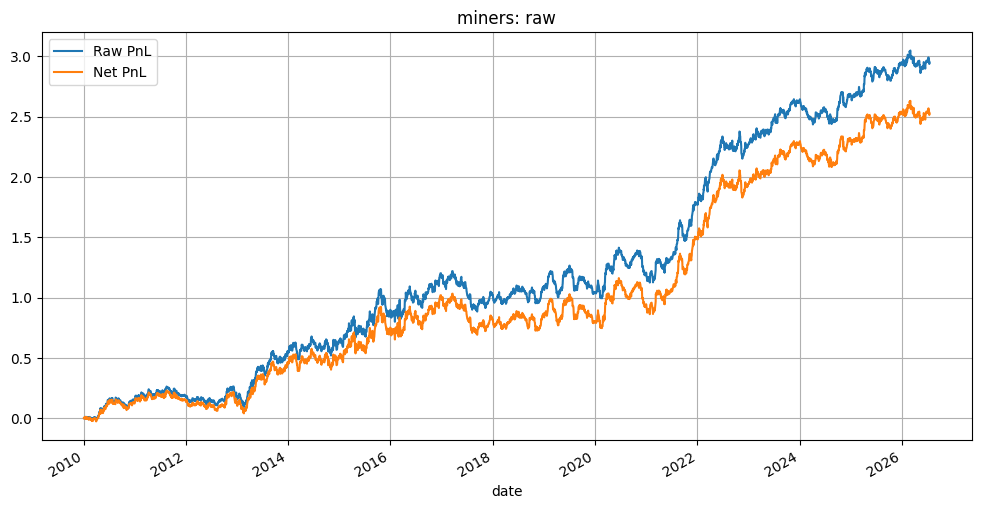

In [32]:
miner_config = SLEEVE_CONFIG['miners']
print(f"Using miners feature: {miner_config['feature']} ({MINER_FEATURE_VERSION})")
df_miner, df_ret = calc_sig('miners', 'METALS')

df_miner_pos, df_miner_target = calc_pos_with_future(df_miner, [target_date])
df_pnl, df_net = calc_pnl(df_miner_pos, df_ret)

pd.DataFrame({
    'Raw PnL': df_pnl.sum(axis=1),
    'Net PnL': df_net.sum(axis=1),
}).cumsum().plot(
    figsize=(12, 6),
    title=f"miners: {MINER_FEATURE_VERSION}",
    grid=True,
)

df_net.to_csv('sim_results/miners.csv', index=True)

calc_stats(df_pnl.sum(axis=1))